In [9]:
import tensorflow as tf
import matplotlib.pyplot as plt
import numpy as np
import cv2


# 1. Load Data

(x_train, y_train), (x_test, y_test) = tf.keras.datasets.mnist.load_data()

# Normalize
x_train = x_train / 255.0
x_test = x_test / 255.0

# Add channel dimension
x_train = x_train[..., np.newaxis]
x_test = x_test[..., np.newaxis]




In [10]:
# 2. Noise Functions

def add_gaussian_noise(images):
    noise = np.random.normal(0, 0.2, images.shape)
    noisy = images + noise
    return np.clip(noisy, 0, 1)


def add_salt_and_pepper_noise(images, prob=0.05):
    noisy = images.copy()
    rand = np.random.rand(*images.shape)

    noisy[rand < prob] = 0
    noisy[rand > 1 - prob] = 1

    return noisy


# Generate noisy data
x_test_gaussian = add_gaussian_noise(x_test)
x_test_sp = add_salt_and_pepper_noise(x_test)

In [ ]:
#lineat and non linear de niusung 
#
# 3. Denoising Filters

def apply_mean_filter(images):
    filtered = []
    for img in images:
        img = img.squeeze()
        mean = cv2.blur(img, (3,3))   # 3x3 mean filter
        filtered.append(mean[..., np.newaxis])
    return np.array(filtered)


def apply_median_filter(images):
    filtered = []
    for img in images:
        img = img.squeeze()
        median = cv2.medianBlur((img*255).astype(np.uint8), 3)
        median = median / 255.0
        filtered.append(median[..., np.newaxis])
    return np.array(filtered)


# Apply filters
x_test_gaussian_denoised = apply_mean_filter(x_test_gaussian)
x_test_sp_denoised = apply_median_filter(x_test_sp)


In [12]:
# 4. Model (CNN)

def create_model():
    from tensorflow.keras import layers, models

    model = models.Sequential([
        layers.Conv2D(32, (3,3), activation='relu', input_shape=(28,28,1)),
        layers.MaxPooling2D(2,2),

        layers.Conv2D(64, (3,3), activation='relu'),
        layers.MaxPooling2D(2,2),

        layers.Flatten(),
        layers.Dense(128, activation='relu'),
        layers.Dense(10, activation='softmax')
    ])

    model.compile(
        optimizer='adam',
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )

    return model


# Train model
model = create_model()
model.fit(x_train, y_train, epochs=5, validation_split=0.1, verbose=1)

Epoch 1/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 15s 8ms/step - accuracy: 0.9557 - loss: 0.1433 - val_accuracy: 0.9863 - val_loss: 0.0496
Epoch 2/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 11s 7ms/step - accuracy: 0.9855 - loss: 0.0465 - val_accuracy: 0.9892 - val_loss: 0.0390
Epoch 3/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 12s 7ms/step - accuracy: 0.9899 - loss: 0.0313 - val_accuracy: 0.9882 - val_loss: 0.0382
Epoch 4/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 12s 7ms/step - accuracy: 0.9926 - loss: 0.0224 - val_accuracy: 0.9903 - val_loss: 0.0352
Epoch 5/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 11s 7ms/step - accuracy: 0.9946 - loss: 0.0160 - val_accuracy: 0.9903 - val_loss: 0.0392


In [13]:
# 5. Accuracy Evaluation

clean_acc = model.evaluate(x_test, y_test, verbose=0)[1]
gaussian_acc = model.evaluate(x_test_gaussian, y_test, verbose=0)[1]
sp_acc = model.evaluate(x_test_sp, y_test, verbose=0)[1]

gaussian_denoised_acc = model.evaluate(x_test_gaussian_denoised, y_test, verbose=0)[1]
sp_denoised_acc = model.evaluate(x_test_sp_denoised, y_test, verbose=0)[1]


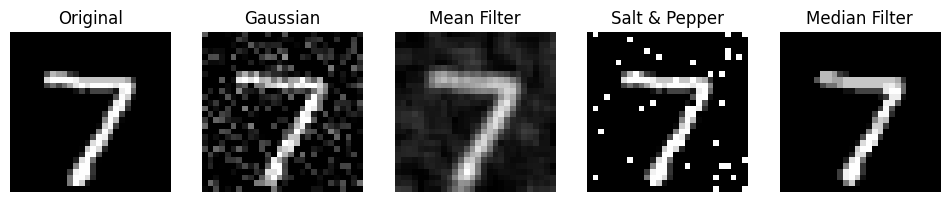

In [15]:
plt.figure(figsize=(12,4))

# Original
plt.subplot(1,5,1)
plt.imshow(x_test[0].squeeze(), cmap='gray')
plt.title("Original")
plt.axis('off')

# Gaussian Noise
plt.subplot(1,5,2)
plt.imshow(x_test_gaussian[0].squeeze(), cmap='gray')
plt.title("Gaussian")
plt.axis('off')

# Mean Filter (Denoised Gaussian)
plt.subplot(1,5,3)
plt.imshow(x_test_gaussian_denoised[0].squeeze(), cmap='gray')
plt.title("Mean Filter")
plt.axis('off')

# Salt & Pepper Noise
plt.subplot(1,5,4)
plt.imshow(x_test_sp[0].squeeze(), cmap='gray')
plt.title("Salt & Pepper")
plt.axis('off')

# Median Filter (Denoised S&P)
plt.subplot(1,5,5)
plt.imshow(x_test_sp_denoised[0].squeeze(), cmap='gray')
plt.title("Median Filter")
plt.axis('off')

plt.show()

In [16]:
# 6. Print Results

print(f"Clean Accuracy: {clean_acc:.4f}")
print(f"Gaussian Noise Accuracy: {gaussian_acc:.4f}")
print(f"Salt & Pepper Accuracy: {sp_acc:.4f}")
print(f"Gaussian + Mean Filter Accuracy: {gaussian_denoised_acc:.4f}")
print(f"Salt & Pepper + Median Filter Accuracy: {sp_denoised_acc:.4f}")

Clean Accuracy: 0.9902
Gaussian Noise Accuracy: 0.9869
Salt & Pepper Accuracy: 0.9630
Gaussian + Mean Filter Accuracy: 0.9746
Salt & Pepper + Median Filter Accuracy: 0.9751
